In [2]:
# Imports

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [3]:
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/dd4real2k/code/mlbh/GridZero


In [4]:
from python_scripts.data_to_bigquery import load_from_bigquery
from python_scripts.hgb_pipeline import hgb_train_preproc

In [5]:
# Load Dataset from BigQuery

client = bigquery.Client(project="gridzero-489711")

query = """
SELECT *
FROM `gridzero-489711.merged_set.full_feature_engineered_data_test`
ORDER BY datetime
"""

df = client.query(query).to_dataframe()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (148991, 31)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,carbon_intensity_gco2_kwh,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520
0,2017-09-12 00:00:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,142.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
1,2017-09-12 00:30:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,140.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
2,2017-09-12 01:00:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,139.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
3,2017-09-12 01:30:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,137.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
4,2017-09-12 02:00:00+00:00,10.9,29.6,25.2,7.0,0.0,0.0,0.0,1002.4,0.0,...,132.0,0.500000,0.866025,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN


In [6]:
# target and datetime columns
target_col = "carbon_intensity_gco2_kwh"
datetime_col = "datetime"

In [7]:
# preprocess dataset once
df = hgb_train_preproc(
    df,
    target_col=target_col,
    datetime_col=datetime_col
)

print("Processed dataset shape:", df.shape)
df.head()

Processed dataset shape: (130766, 33)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520,carbon_roll_24h,carbon_roll_168h
0,2018-09-15 12:00:00+00:00,19.2,17.2,27.7,98.0,490.0,303.0,187.0,1024.2,0.0,...,-1.000000,-0.974928,-0.222521,-0.963471,-0.267814,211.0,255.0,270.0,239.625000,228.375000
1,2018-09-15 12:30:00+00:00,19.2,17.2,27.7,98.0,490.0,303.0,187.0,1024.2,0.0,...,-1.000000,-0.974928,-0.222521,-0.963471,-0.267814,212.0,255.0,249.0,243.875000,229.077381
2,2018-09-15 13:00:00+00:00,19.5,17.9,26.6,99.0,364.0,118.0,246.0,1023.8,0.0,...,-0.965926,-0.974928,-0.222521,-0.963471,-0.267814,214.0,248.0,262.0,247.708333,229.785714
3,2018-09-15 13:30:00+00:00,19.5,17.9,26.6,99.0,364.0,118.0,246.0,1023.8,0.0,...,-0.965926,-0.974928,-0.222521,-0.963471,-0.267814,215.0,239.0,251.0,251.250000,230.446429
4,2018-09-15 14:00:00+00:00,19.5,15.7,26.3,99.0,257.0,46.0,211.0,1023.4,0.0,...,-0.866025,-0.974928,-0.222521,-0.963471,-0.267814,203.0,235.0,257.0,254.208333,231.065476


In [8]:
# Build X and y
X = df.drop(columns=[target_col, datetime_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (130766, 31)
y shape: (130766,)


In [9]:
# Time based split

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (104612, 31) (104612,)
Test shapes: (26154, 31) (26154,)


In [10]:
# Models

models = {
    "HGB": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_depth=10,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=10,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [11]:
# Initialize results

results = []
predictions = {}
trained_models = {}

In [12]:
# Train all models and store predictions

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    trained_models[name] = model
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


Training HGB...

Training Random Forest...

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038052 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6579
[LightGBM] [Info] Number of data points in the train set: 104612, number of used features: 31
[LightGBM] [Info] Start training from score 178.787215

Training XGBoost...


In [13]:

print("Available prediction keys:")
print(predictions.keys())

Available prediction keys:
dict_keys(['HGB', 'Random Forest', 'LightGBM', 'XGBoost'])


In [14]:
# Base comparison table
comparison_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
comparison_df

,Model,MAE,RMSE,R2
0,XGBoost,9.053274,11.748640,0.960058
1,LightGBM,9.399578,12.222107,0.956774
2,HGB,9.913468,12.911356,0.951761
3,Random Forest,12.150948,15.612243,0.929469


In [15]:
# Model predictions

pred_hgb = predictions["HGB"]
pred_rf = predictions["Random Forest"]
pred_lgbm = predictions["LightGBM"]
pred_xgb = predictions["XGBoost"]

In [16]:
# Equal ensemble
ensemble_preds_equal = (
    pred_hgb + pred_rf + pred_lgbm + pred_xgb
) / 4

In [17]:
# Evaluate equal ensemble

ensemble_mae_equal = mean_absolute_error(y_test, ensemble_preds_equal)
ensemble_rmse_equal = mean_squared_error(y_test, ensemble_preds_equal) ** 0.5
ensemble_r2_equal = r2_score(y_test, ensemble_preds_equal)

print("Equal Ensemble MAE :", round(ensemble_mae_equal, 4))
print("Equal Ensemble RMSE:", round(ensemble_rmse_equal, 4))
print("Equal Ensemble R2  :", round(ensemble_r2_equal, 4))

Equal Ensemble MAE : 9.5348
Equal Ensemble RMSE: 12.4155
Equal Ensemble R2  : 0.9554


In [18]:
# weighted ensemble
ensemble_preds_weighted = (
    0.4 * pred_lgbm +
    0.3 * pred_xgb +
    0.2 * pred_hgb +
    0.1 * pred_rf
)

In [19]:
# Evaluate weighted ensemble
ensemble_mae_weighted = mean_absolute_error(y_test, ensemble_preds_weighted)
ensemble_rmse_weighted = mean_squared_error(y_test, ensemble_preds_weighted) ** 0.5
ensemble_r2_weighted = r2_score(y_test, ensemble_preds_weighted)

print("Weighted Ensemble MAE :", round(ensemble_mae_weighted, 4))
print("Weighted Ensemble RMSE:", round(ensemble_rmse_weighted, 4))
print("Weighted Ensemble R2  :", round(ensemble_r2_weighted, 4))

Weighted Ensemble MAE : 9.2474
Weighted Ensemble RMSE: 12.0436
Weighted Ensemble R2  : 0.958


In [20]:
# Top-2 ensemble

ensemble_preds_top2 = (
    0.6 * pred_lgbm +
    0.4 * pred_xgb
)

In [21]:
# Top-2 ensemble
ensemble_mae_top2 = mean_absolute_error(y_test, ensemble_preds_top2)
ensemble_rmse_top2 = mean_squared_error(y_test, ensemble_preds_top2) ** 0.5
ensemble_r2_top2 = r2_score(y_test, ensemble_preds_top2)

print("Top-2 Ensemble MAE :", round(ensemble_mae_top2, 4))
print("Top-2 Ensemble RMSE:", round(ensemble_rmse_top2, 4))
print("Top-2 Ensemble R2  :", round(ensemble_r2_top2, 4))

Top-2 Ensemble MAE : 9.0488
Top-2 Ensemble RMSE: 11.7802
Top-2 Ensemble R2  : 0.9598


In [22]:
# ensemble comparison table
ensemble_df = pd.DataFrame([
    {
        "Model": "Ensemble Equal",
        "MAE": ensemble_mae_equal,
        "RMSE": ensemble_rmse_equal,
        "R2": ensemble_r2_equal
    },
    {
        "Model": "Ensemble Weighted",
        "MAE": ensemble_mae_weighted,
        "RMSE": ensemble_rmse_weighted,
        "R2": ensemble_r2_weighted
    },
    {
        "Model": "Ensemble Top 2",
        "MAE": ensemble_mae_top2,
        "RMSE": ensemble_rmse_top2,
        "R2": ensemble_r2_top2
    }
]).sort_values("RMSE").reset_index(drop=True)

ensemble_df

,Model,MAE,RMSE,R2
0,Ensemble Top 2,9.048764,11.780154,0.959844
1,Ensemble Weighted,9.247446,12.043591,0.958028
2,Ensemble Equal,9.534755,12.415461,0.955396


In [23]:
# Merge individual models + ensemble results

comparison_with_ensemble = pd.concat(
    [comparison_df, ensemble_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

comparison_with_ensemble

,Model,MAE,RMSE,R2
0,XGBoost,9.053274,11.748640,0.960058
1,Ensemble Top 2,9.048764,11.780154,0.959844
2,Ensemble Weighted,9.247446,12.043591,0.958028
3,LightGBM,9.399578,12.222107,0.956774
4,Ensemble Equal,9.534755,12.415461,0.955396
5,HGB,9.913468,12.911356,0.951761
6,Random Forest,12.150948,15.612243,0.929469


In [24]:
# Best overall model
print("Best overall model by RMSE:")
print(comparison_with_ensemble.iloc[0])

Best overall model by RMSE:
Model     XGBoost
MAE      9.053274
RMSE     11.74864
R2       0.960058
Name: 0, dtype: object


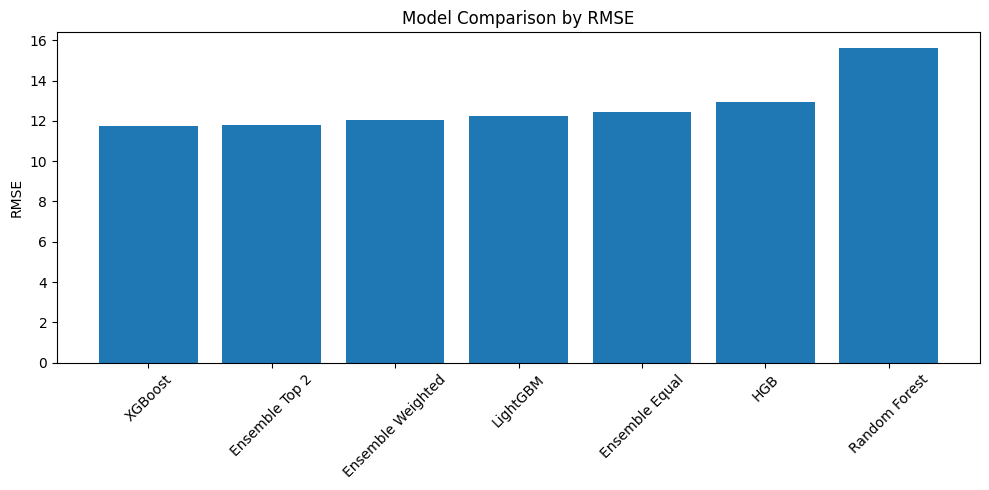

In [25]:
# Plot RMSE comparison

plt.figure(figsize=(10, 5))
plt.bar(comparison_with_ensemble["Model"], comparison_with_ensemble["RMSE"])
plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

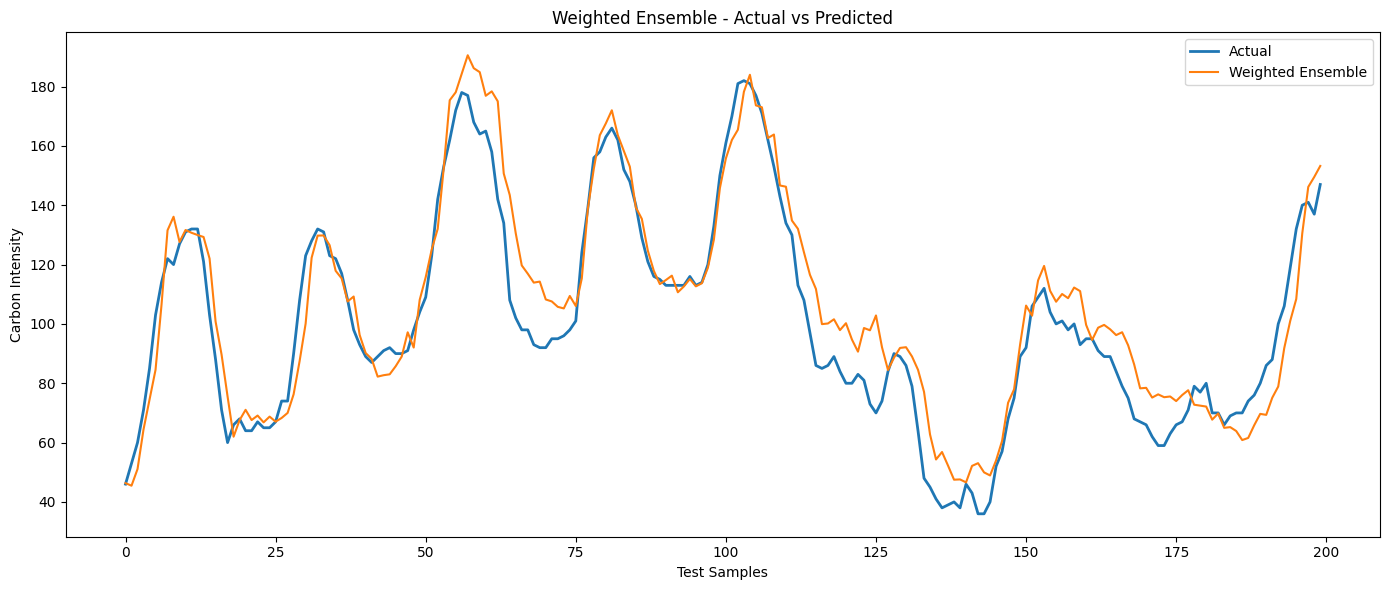

In [ ]:
# actual vs weighted ensemble

plt.figure(figsize=(14, 6))
plt.plot(y_test.values[:200], label="Actual", linewidth=2)
plt.plot(ensemble_preds_weighted[:200], label="Weighted Ensemble")

plt.title("Weighted Ensemble - Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Carbon Intensity")
plt.legend()
plt.tight_layout()
plt.show()

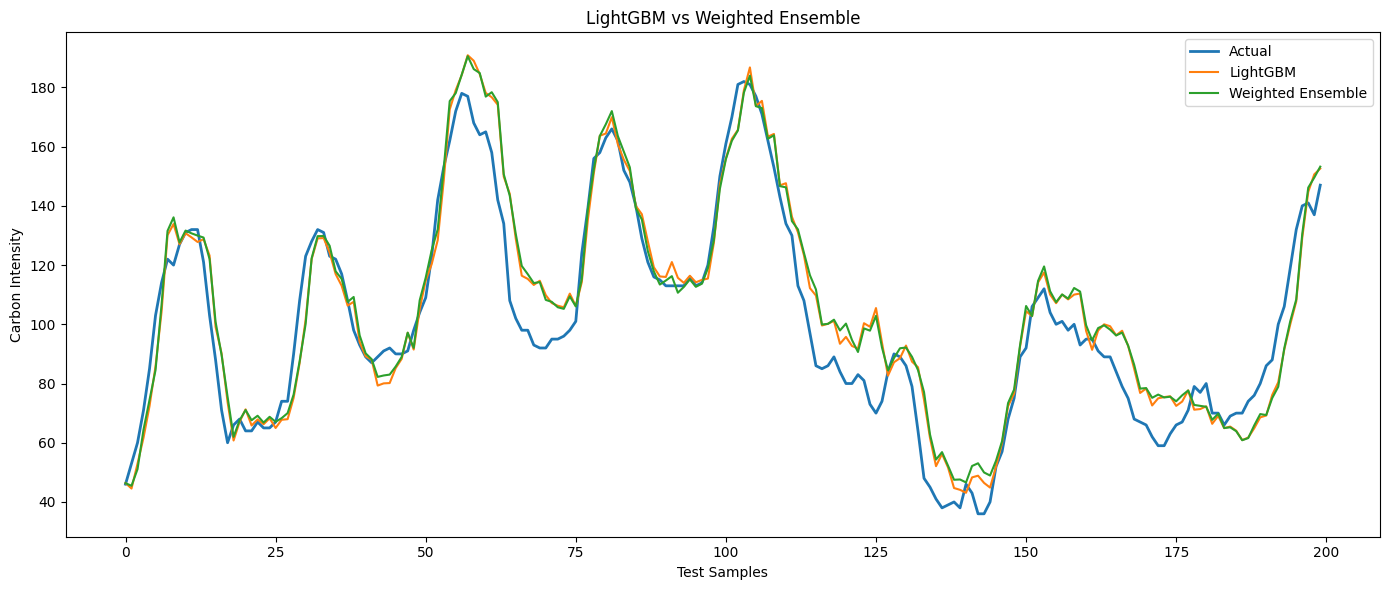

In [27]:
# Best individual vs ensemble
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[:200], label="Actual", linewidth=2)
plt.plot(pred_lgbm[:200], label="LightGBM")
plt.plot(ensemble_preds_weighted[:200], label="Weighted Ensemble")

plt.title("LightGBM vs Weighted Ensemble")
plt.xlabel("Test Samples")
plt.ylabel("Carbon Intensity")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Save ensemble predictions
ensemble_results_df = pd.DataFrame({
    "actual": y_test.values,
    "ensemble_equal": ensemble_preds_equal,
    "ensemble_weighted": ensemble_preds_weighted,
    "ensemble_top2": ensemble_preds_top2
})

ensemble_results_df.head()

,actual,ensemble_equal,ensemble_weighted,ensemble_top2
0,46.0,46.366894,46.340298,46.181904
1,53.0,45.790992,45.472425,45.665544
2,60.0,50.918513,51.075149,51.358129
3,71.0,65.628419,64.439188,63.537575
4,85.0,75.426960,74.490322,73.307850


In [29]:
comparison_with_ensemble.to_csv("../models/comparison_with_ensemble.csv", index=False)
ensemble_results_df.to_csv("../models/ensemble_predictions.csv", index=False)

print("Saved ensemble comparison and predictions.")

Saved ensemble comparison and predictions.
